In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'tcav-v2-quality-tcav_rows.csv').exists():
    REPO_ROOT = REPO_ROOT.parent

rows_df = pd.read_csv(REPO_ROOT / 'tcav-v2-quality-tcav_rows.csv')

SEED = 1337
ENROLL_COUNT = 19
TEST_COUNT = 1
EXAMPLES = ['id00012', 'id00016', 'id00018']

speakers = sorted(rows_df['true label'].unique().tolist())
concepts = sorted(rows_df['concept name'].unique().tolist())

print(f'Speakers:              {len(speakers)}')
print(f'Concepts:              {len(concepts)}')
recs = rows_df.groupby('true label')['path'].nunique().iloc[0]
print(f'Recordings / speaker:  {recs}')
print(f'Total rows:            {len(rows_df):,}')
print()
print(f'Example speakers we will follow: {EXAMPLES}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.sparse import csr_matrix, issparse


Speakers:              10
Concepts:              28
Recordings / speaker:  20
Total rows:            44,800

Example speakers we will follow: ['id00012', 'id00016', 'id00018']


## Step 1 — Enrollment / Test Split

Each speaker has **20 recordings**.  We shuffle them with a fixed seed, hold
out **1 recording for testing**, and keep the remaining **19 for enrollment**.

The enrollment recordings build the speaker's *concept fingerprint*.
The single test recording checks whether we can identify the speaker.

In [2]:
enroll_parts, test_parts = [], []
test_recording = {}  # speaker → held-out path

for spk in speakers:
    spk_df = rows_df[rows_df['true label'] == spk]
    paths = sorted(spk_df['path'].dropna().astype(str).unique().tolist())
    shuffled = pd.Series(paths).sample(frac=1.0, random_state=SEED).tolist()

    t_paths = set(shuffled[:TEST_COUNT])
    e_paths = set(shuffled[TEST_COUNT : TEST_COUNT + ENROLL_COUNT])

    test_parts.append(spk_df[spk_df['path'].isin(t_paths)])
    enroll_parts.append(spk_df[spk_df['path'].isin(e_paths)])
    test_recording[spk] = list(t_paths)[0]

enroll_df = pd.concat(enroll_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

print(f'Enrollment rows: {len(enroll_df):,}    Test rows: {len(test_df):,}')
print()
for spk in EXAMPLES:
    n_e = enroll_df[enroll_df['true label'] == spk]['path'].nunique()
    n_t = test_df[test_df['true label'] == spk]['path'].nunique()
    fname = test_recording[spk].rsplit('/', 1)[-1]
    print(f'  {spk}:  {n_e} enrollment  |  {n_t} test  \u2192  {fname}')

Enrollment rows: 42,560    Test rows: 2,240

  id00012:  19 enrollment  |  1 test  →  00006.m4a
  id00016:  19 enrollment  |  1 test  →  00006.m4a
  id00018:  19 enrollment  |  1 test  →  00006.m4a


## Step 2 — Computing the Enrollment Concept Vector

For each speaker we average `pos_effect_delta` across all **19 enrollment
recordings** and all random baselines, **per concept**, producing a
**28-dimensional vector**.

* **Positive value** → the concept pushes the model *toward* identifying this speaker.
* **Negative value** → the concept pushes the model *away*.

This vector is the speaker's **concept fingerprint**.

Enrollment matrix: 10 speakers × 28 concepts



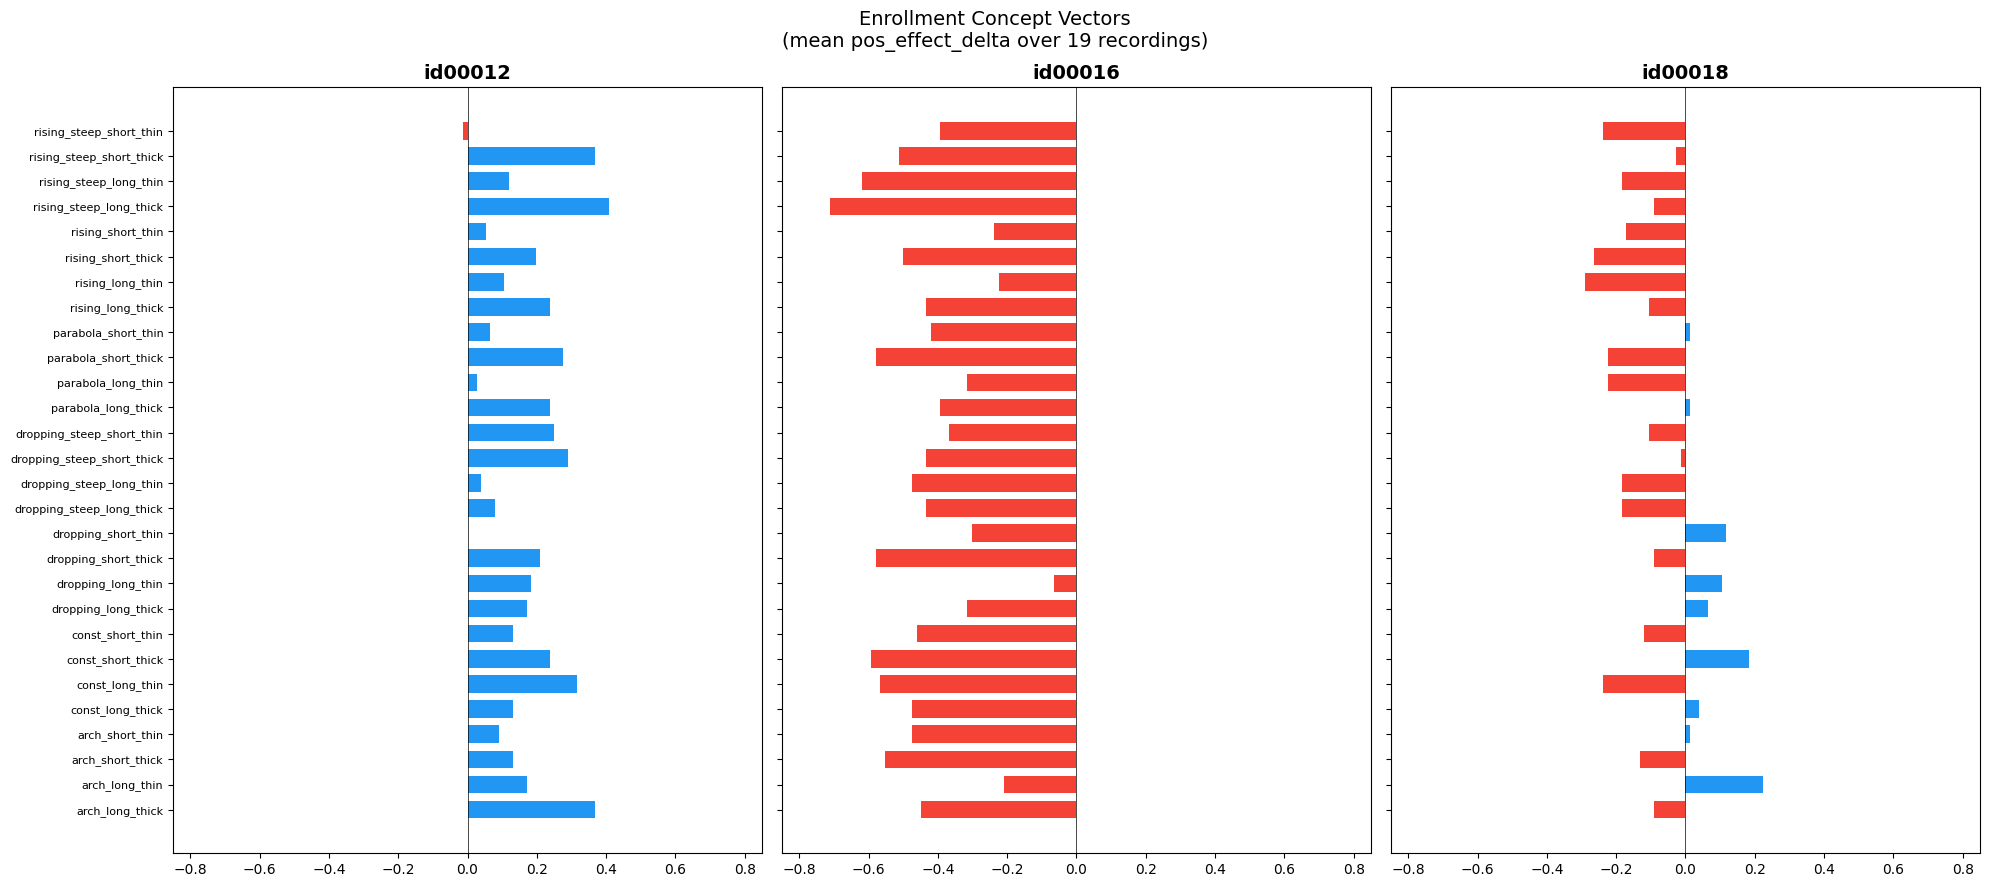

In [3]:
# Average pos_effect_delta per (speaker, concept) across 19 enrollment recordings
enrollment_matrix = (
    enroll_df
    .groupby(['true label', 'concept name'])['pos_effect_delta']
    .mean()
    .unstack(fill_value=0.0)
    .reindex(columns=concepts, fill_value=0.0)
    .sort_index()
)

print(f'Enrollment matrix: {enrollment_matrix.shape[0]} speakers \u00d7 '
      f'{enrollment_matrix.shape[1]} concepts')
print()

# Bar chart for the 3 example speakers
fig, axes = plt.subplots(1, 3, figsize=(20, 9), sharey=True)
for i, (ax, spk) in enumerate(zip(axes, EXAMPLES)):
    vec = enrollment_matrix.loc[spk]
    colors = ['#2196F3' if v >= 0 else '#f44336' for v in vec]
    ax.barh(concepts, vec.values, color=colors, height=0.7)
    ax.set_title(spk, fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-0.85, 0.85)
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle(
    'Enrollment Concept Vectors\n'
    '(mean pos_effect_delta over 19 recordings)',
    fontsize=14,
)
plt.tight_layout()
plt.show()

## Step 3 — Test Recording → Sign Vector

For the **single held-out recording** we compute the same per-concept average,
then collapse each value to a **sign**: **+1** if positive, **−1** otherwise.

The sign vector captures the *direction* of each concept's influence, discarding
magnitude.  It is the "question" we match against each speaker's enrollment
fingerprint.

In [4]:
# Raw concept vector for each speaker's single test recording
test_raw = {}
for spk in speakers:
    spk_test = test_df[test_df['true label'] == spk]
    vec = spk_test.groupby('concept name')['pos_effect_delta'].mean()
    test_raw[spk] = vec.reindex(concepts, fill_value=0.0)

# Convert to sign vectors: +1 if positive, -1 otherwise
test_signs = {}
for spk, vec in test_raw.items():
    test_signs[spk] = vec.apply(lambda x: 1.0 if x > 0 else -1.0)

# Show raw \u2192 sign conversion for the 3 example speakers
for spk in EXAMPLES:
    raw = test_raw[spk]
    signs = test_signs[spk]
    print(f'\n{"=" * 68}')
    print(f'  {spk}  \u2014  test: ...{test_recording[spk].rsplit("/", 1)[-1]}')
    print(f'{"=" * 68}')
    print(f'  {"Concept":30s}  {"Raw":>10s}  \u2192  {"Sign":>5s}')
    print(f'  {"-" * 55}')
    for c in concepts:
        sign_str = '+1' if signs[c] > 0 else '-1'
        print(f'  {c:30s}  {raw[c]:+10.4f}  \u2192  {sign_str:>5s}')


  id00012  —  test: ...00006.m4a
  Concept                                Raw  →   Sign
  -------------------------------------------------------
  arch_long_thick                    +1.0000  →     +1
  arch_long_thin                     +1.0000  →     +1
  arch_short_thick                   +1.0000  →     +1
  arch_short_thin                    +1.0000  →     +1
  const_long_thick                   +1.0000  →     +1
  const_long_thin                    +1.0000  →     +1
  const_short_thick                  +0.7500  →     +1
  const_short_thin                   +1.0000  →     +1
  dropping_long_thick                +1.0000  →     +1
  dropping_long_thin                 +1.0000  →     +1
  dropping_short_thick               +1.0000  →     +1
  dropping_short_thin                +0.7500  →     +1
  dropping_steep_long_thick          +1.0000  →     +1
  dropping_steep_long_thin           +1.0000  →     +1
  dropping_steep_short_thick         +1.0000  →     +1
  dropping_steep_short_thin 

## Step 4 — Scoring: Enrollment Vector × Sign Vector

For each *(test recording, speaker)* pair the score is:

$$\text{score} = \sum_{i=1}^{28} \text{enrollment}_i \times \text{sign}_i$$

**Intuition**: If the enrollment value is positive where the sign is +1 and
negative where the sign is −1, the products are all positive → high score →
good match.  When they disagree the products are negative → low score.

We first walk through the **element-wise multiplication** for one example,
then score all speakers.

In [5]:
def print_scoring_detail(test_spk, enroll_spk):
    enroll_vec = enrollment_matrix.loc[enroll_spk]
    sign_vec = test_signs[test_spk]
    products = enroll_vec * sign_vec

    tag = 'SELF-MATCH' if test_spk == enroll_spk else 'CROSS-SPEAKER'
    print(f'\n  {test_spk} test  \u00d7  {enroll_spk} enrollment   [{tag}]')
    print(f'  {"\u2500" * 66}')
    print(f'  {"Concept":30s} {"Enroll":>8s} \u00d7 {"Sign":>4s} = {"Product":>8s}')
    print(f'  {"\u2500" * 66}')
    for c in concepts:
        e = enroll_vec[c]
        s = sign_vec[c]
        p = products[c]
        sign_str = '+1' if s > 0 else '-1'
        mark = '\u2713' if p > 0 else '\u2717'
        print(f'  {c:30s} {e:+8.4f} \u00d7 {sign_str:>4s} = {p:+8.4f}  {mark}')
    print(f'  {"\u2500" * 66}')
    total = products.sum()
    print(f'  {"TOTAL SCORE":30s} {"":>8s}   {"":>4s}   {total:+8.4f}')
    return total

# Self-match: id00012 test vs id00012 enrollment
score_self = print_scoring_detail(EXAMPLES[0], EXAMPLES[0])

# Cross-speaker: id00012 test vs id00016 enrollment
score_cross = print_scoring_detail(EXAMPLES[0], EXAMPLES[1])

print(f'\n\n  Summary:')
print(f'    Self-match score  ({EXAMPLES[0]} vs {EXAMPLES[0]}): {score_self:+.4f}')
print(f'    Cross-match score ({EXAMPLES[0]} vs {EXAMPLES[1]}): {score_cross:+.4f}')


  id00012 test  ×  id00012 enrollment   [SELF-MATCH]
  ──────────────────────────────────────────────────────────────────
  Concept                          Enroll × Sign =  Product
  ──────────────────────────────────────────────────────────────────
  arch_long_thick                 +0.3684 ×   +1 =  +0.3684  ✓
  arch_long_thin                  +0.1711 ×   +1 =  +0.1711  ✓
  arch_short_thick                +0.1316 ×   +1 =  +0.1316  ✓
  arch_short_thin                 +0.0921 ×   +1 =  +0.0921  ✓
  const_long_thick                +0.1316 ×   +1 =  +0.1316  ✓
  const_long_thin                 +0.3158 ×   +1 =  +0.3158  ✓
  const_short_thick               +0.2368 ×   +1 =  +0.2368  ✓
  const_short_thin                +0.1316 ×   +1 =  +0.1316  ✓
  dropping_long_thick             +0.1711 ×   +1 =  +0.1711  ✓
  dropping_long_thin              +0.1842 ×   +1 =  +0.1842  ✓
  dropping_short_thick            +0.2105 ×   +1 =  +0.2105  ✓
  dropping_short_thin             +0.0000 ×   +1 =  +0.

In [6]:
# Score every test recording against every enrollment vector
score_rows = []
for test_spk in speakers:
    signs = test_signs[test_spk]
    for enroll_spk in speakers:
        score = float((enrollment_matrix.loc[enroll_spk] * signs).sum())
        score_rows.append({
            'test_speaker': test_spk,
            'vs_speaker': enroll_spk,
            'score': score,
        })

scores_df = pd.DataFrame(score_rows)

# Best match per test speaker
best = (
    scores_df.sort_values('score', ascending=False)
    .groupby('test_speaker')
    .first()
    .reset_index()
)
best['correct'] = best['test_speaker'] == best['vs_speaker']

# Show rankings for the 3 example speakers
for test_spk in EXAMPLES:
    ranked = scores_df[scores_df['test_speaker'] == test_spk].sort_values(
        'score', ascending=False,
    )
    top_spk = ranked.iloc[0]['vs_speaker']
    print(f'\n{test_spk} test recording \u2014 scores vs all speakers:')
    for _, row in ranked.iterrows():
        flags = ''
        if row['vs_speaker'] == test_spk:
            flags += ' \u2190 TRUE'
        if row['vs_speaker'] == top_spk:
            flags += ' \u2605 BEST'
        print(f'  vs {row["vs_speaker"]}  {row["score"]:+8.3f}{flags}')


id00012 test recording — scores vs all speakers:
  vs id00025   +18.263 ★ BEST
  vs id00024   +15.092
  vs id00019    +8.579
  vs id00012    +4.882 ← TRUE
  vs id00021    +3.105
  vs id00018    -2.197
  vs id00026    -7.474
  vs id00020    -7.803
  vs id00016   -12.092
  vs id00022   -23.895

id00016 test recording — scores vs all speakers:
  vs id00025   +18.263 ★ BEST
  vs id00024   +15.092
  vs id00019    +8.579
  vs id00012    +4.882
  vs id00021    +3.105
  vs id00018    -2.197
  vs id00026    -7.474
  vs id00020    -7.803
  vs id00016   -12.092 ← TRUE
  vs id00022   -23.895

id00018 test recording — scores vs all speakers:
  vs id00022   +23.895 ★ BEST
  vs id00016   +12.092
  vs id00020    +7.803
  vs id00026    +7.474
  vs id00018    +2.197 ← TRUE
  vs id00021    -3.105
  vs id00012    -4.882
  vs id00019    -8.579
  vs id00024   -15.092
  vs id00025   -18.263


## Step 5 — Full Results & Visualization

We now look at the complete **score matrix**, overall identification
**accuracy**, **K-Means clustering** of enrollment vectors, and a **PCA
scatter** plot.

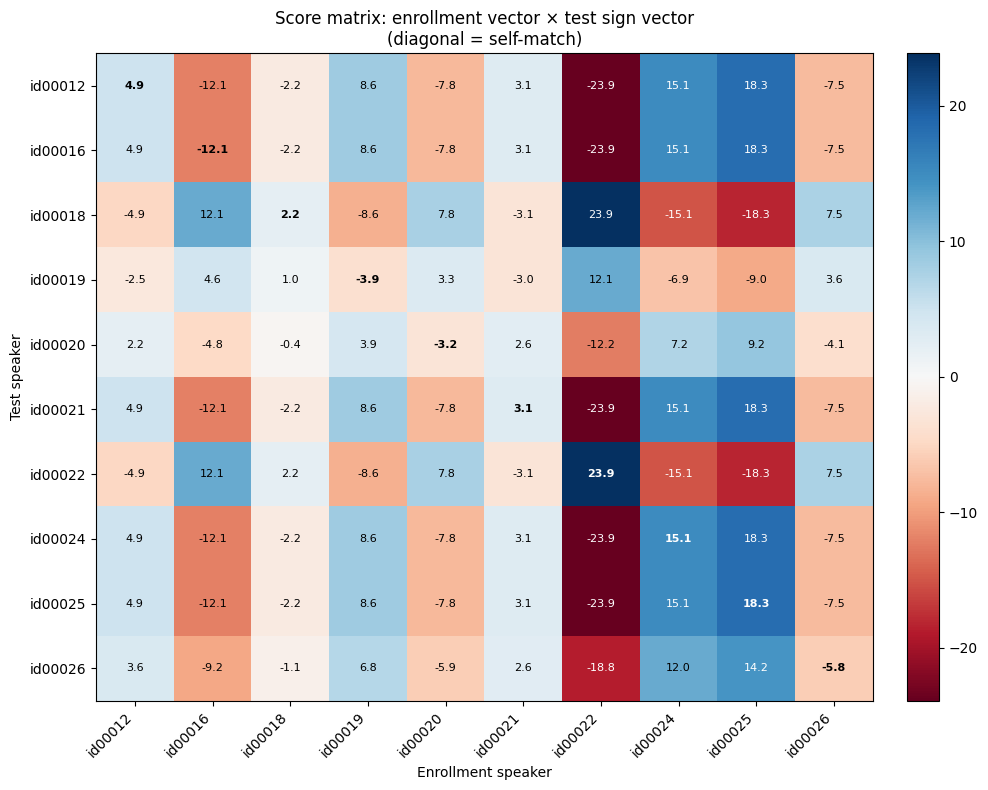

Identification accuracy: 2/10 (20%)

  id00012  →  predicted id00025  ✗
  id00016  →  predicted id00025  ✗
  id00018  →  predicted id00022  ✗
  id00019  →  predicted id00022  ✗
  id00020  →  predicted id00025  ✗
  id00021  →  predicted id00025  ✗
  id00022  →  predicted id00022  ✓
  id00024  →  predicted id00025  ✗
  id00025  →  predicted id00025  ✓
  id00026  →  predicted id00025  ✗


In [7]:
# Score matrix heatmap (rows=test, columns=enrollment)
score_matrix = scores_df.pivot(
    index='test_speaker', columns='vs_speaker', values='score',
).reindex(index=speakers, columns=speakers)

fig, ax = plt.subplots(figsize=(10, 8))
vmax = max(abs(score_matrix.values.min()), abs(score_matrix.values.max()))
im = ax.imshow(score_matrix.values, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(speakers)))
ax.set_yticks(range(len(speakers)))
ax.set_xticklabels(speakers, rotation=45, ha='right')
ax.set_yticklabels(speakers)
ax.set_xlabel('Enrollment speaker')
ax.set_ylabel('Test speaker')
ax.set_title('Score matrix: enrollment vector \u00d7 test sign vector\n(diagonal = self-match)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(speakers)):
    for j in range(len(speakers)):
        v = score_matrix.values[i, j]
        color = 'white' if abs(v) > vmax * 0.55 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                color=color, fontsize=8, fontweight=weight)
plt.tight_layout()
plt.show()

# Accuracy
n_correct = int(best['correct'].sum())
n_total = len(best)
print(f'Identification accuracy: {n_correct}/{n_total} ({n_correct / n_total:.0%})')
print()
for _, row in best.sort_values('test_speaker').iterrows():
    status = '\u2713' if row['correct'] else '\u2717'
    print(f'  {row["test_speaker"]}  \u2192  predicted {row["vs_speaker"]}  {status}')

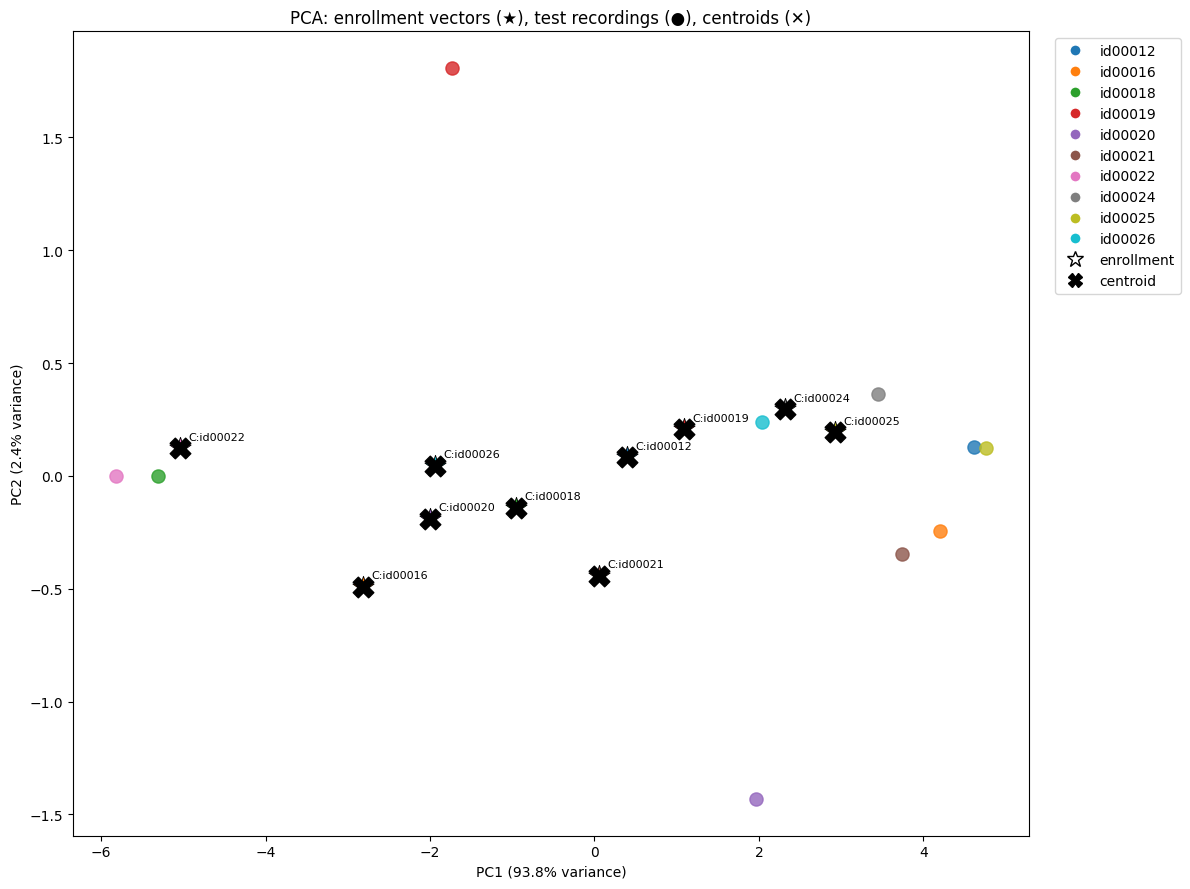

In [8]:
# K-Means clustering on enrollment vectors
n_clusters = len(speakers)
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init='auto')
cluster_labels = kmeans.fit_predict(enrollment_matrix.values)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=concepts)

cluster_to_speaker = {}
for spk, lbl in zip(enrollment_matrix.index, cluster_labels):
    cluster_to_speaker[int(lbl)] = str(spk)

# Prepare PCA data
enroll_pca = enrollment_matrix.copy()
enroll_pca['point_type'] = 'enrollment'
enroll_pca['speaker'] = enroll_pca.index.astype(str)
enroll_pca = enroll_pca.reset_index(drop=True)

test_pca = pd.DataFrame(test_raw).T.reindex(columns=concepts, fill_value=0.0)
test_pca['point_type'] = 'test'
test_pca['speaker'] = test_pca.index.astype(str)
test_pca = test_pca.reset_index(drop=True)

cent_pca = centroids.copy()
cent_pca['point_type'] = 'centroid'
cent_pca['speaker'] = [cluster_to_speaker[i] for i in range(n_clusters)]

all_pts = pd.concat([enroll_pca, test_pca, cent_pca], ignore_index=True)

pca = PCA(n_components=2, random_state=SEED)
xy = pca.fit_transform(all_pts[concepts].values)
all_pts['pc1'] = xy[:, 0]
all_pts['pc2'] = xy[:, 1]

# Plot
cmap = {spk: plt.cm.tab10(i % 10) for i, spk in enumerate(speakers)}
fig, ax = plt.subplots(figsize=(12, 9))

for spk in speakers:
    ev = all_pts[(all_pts['point_type'] == 'enrollment') & (all_pts['speaker'] == spk)]
    tv = all_pts[(all_pts['point_type'] == 'test') & (all_pts['speaker'] == spk)]
    ax.scatter(ev['pc1'], ev['pc2'], marker='*', s=260, color=cmap[spk],
               edgecolors='black', linewidths=0.6, zorder=3)
    ax.scatter(tv['pc1'], tv['pc2'], marker='o', s=90, color=cmap[spk],
               alpha=0.8, zorder=2, label=spk)

cv = all_pts[all_pts['point_type'] == 'centroid']
ax.scatter(cv['pc1'], cv['pc2'], marker='X', s=220, color='black', zorder=4)
for _, row in cv.iterrows():
    ax.annotate(f'C:{row["speaker"]}', (row['pc1'], row['pc2']),
                textcoords='offset points', xytext=(6, 6), fontsize=8)

handles = [
    Line2D([0], [0], marker='o', color='w', label=s,
           markerfacecolor=cmap[s], markersize=8)
    for s in speakers
] + [
    Line2D([0], [0], marker='*', color='k', label='enrollment',
           markerfacecolor='w', markersize=12, linewidth=0),
    Line2D([0], [0], marker='X', color='k', label='centroid',
           markerfacecolor='k', markersize=10, linewidth=0),
]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('PCA: enrollment vectors (\u2605), test recordings (\u25cf), centroids (\u2715)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

In [9]:
summary = {
    'n_speakers': len(speakers),
    'n_concepts': len(concepts),
    'enrollment_recordings': ENROLL_COUNT,
    'test_recordings': TEST_COUNT,
    'identification_accuracy': f'{n_correct}/{n_total} ({n_correct / n_total:.0%})',
    'mean_best_score': round(float(best['score'].mean()), 2),
}

print('Summary')
print('\u2500' * 40)
for k, v in summary.items():
    print(f'  {k}: {v}')

Summary
────────────────────────────────────────
  n_speakers: 10
  n_concepts: 28
  enrollment_recordings: 19
  test_recordings: 1
  identification_accuracy: 2/10 (20%)
  mean_best_score: 17.46


## Step 1 — Split (80 / 20)

In [10]:
ENROLL_RATIO = 0.80  # ← change this single constant to try other splits

enroll_parts_2, test_parts_2 = [], []
test_recordings_2 = {}  # speaker → list of test paths

for spk in speakers:
    spk_df = rows_df[rows_df['true label'] == spk]
    paths = sorted(spk_df['path'].dropna().astype(str).unique().tolist())
    shuffled = pd.Series(paths).sample(frac=1.0, random_state=SEED).tolist()

    n_enroll = int(round(len(shuffled) * ENROLL_RATIO))
    n_test = len(shuffled) - n_enroll
    assert n_test >= 1, f'{spk}: need at least 1 test recording'

    e_paths = set(shuffled[:n_enroll])
    t_paths = set(shuffled[n_enroll:])

    enroll_parts_2.append(spk_df[spk_df['path'].isin(e_paths)])
    test_parts_2.append(spk_df[spk_df['path'].isin(t_paths)])
    test_recordings_2[spk] = sorted(t_paths)

enroll_df_2 = pd.concat(enroll_parts_2, ignore_index=True)
test_df_2 = pd.concat(test_parts_2, ignore_index=True)

n_e = enroll_df_2.groupby('true label')['path'].nunique().iloc[0]
n_t = test_df_2.groupby('true label')['path'].nunique().iloc[0]
print(f'ENROLL_RATIO = {ENROLL_RATIO}')
print(f'Per speaker:  {n_e} enrollment  |  {n_t} test')
print(f'Total rows:   {len(enroll_df_2):,} enrollment  |  {len(test_df_2):,} test')
print()
for spk in EXAMPLES:
    fnames = [p.rsplit('/', 1)[-1] for p in test_recordings_2[spk]]
    print(f'  {spk}:  test files = {fnames}')

ENROLL_RATIO = 0.8
Per speaker:  16 enrollment  |  4 test
Total rows:   35,840 enrollment  |  8,960 test

  id00012:  test files = ['00008.m4a', '00009.m4a', '00019.m4a', '00020.m4a']
  id00016:  test files = ['00008.m4a', '00009.m4a', '00019.m4a', '00020.m4a']
  id00018:  test files = ['00008.m4a', '00009.m4a', '00019.m4a', '00020.m4a']


## Step 2 — Enrollment Vectors (from 16 recordings)

Enrollment matrix: 10 speakers × 28 concepts


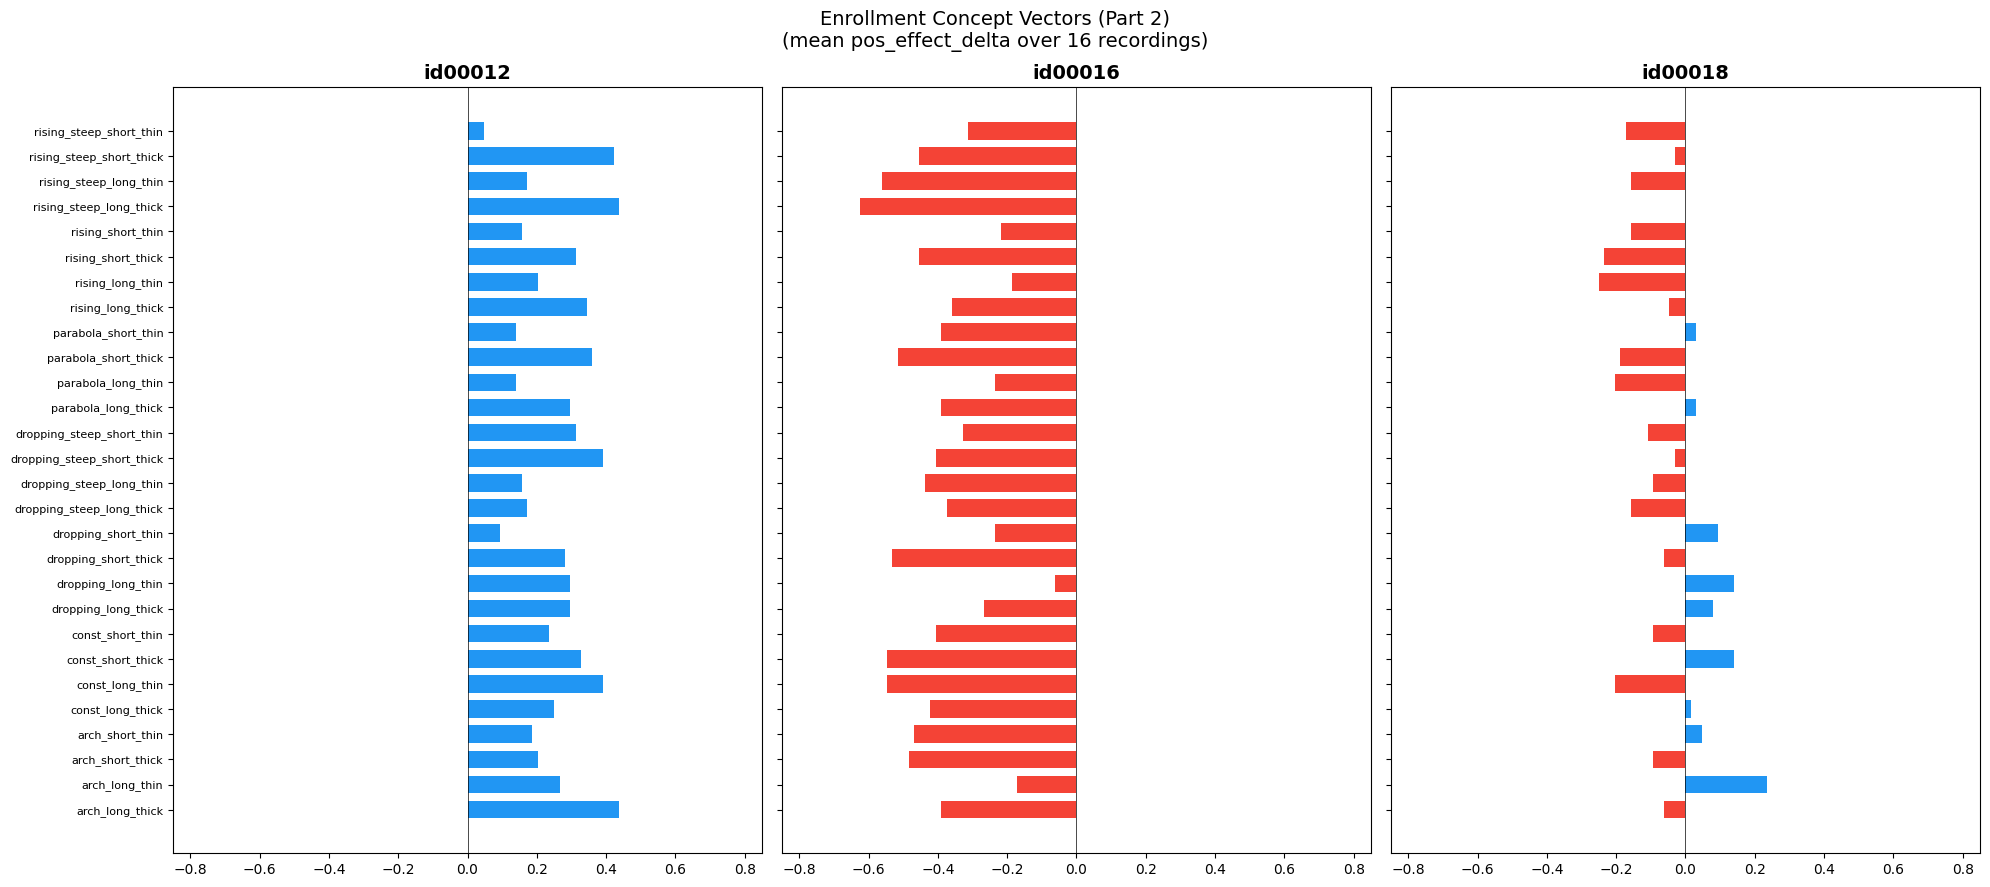

In [11]:
enrollment_matrix_2 = (
    enroll_df_2
    .groupby(['true label', 'concept name'])['pos_effect_delta']
    .mean()
    .unstack(fill_value=0.0)
    .reindex(columns=concepts, fill_value=0.0)
    .sort_index()
)
print(f'Enrollment matrix: {enrollment_matrix_2.shape[0]} speakers \u00d7 '
      f'{enrollment_matrix_2.shape[1]} concepts')

fig, axes = plt.subplots(1, 3, figsize=(20, 9), sharey=True)
for i, (ax, spk) in enumerate(zip(axes, EXAMPLES)):
    vec = enrollment_matrix_2.loc[spk]
    colors = ['#2196F3' if v >= 0 else '#f44336' for v in vec]
    ax.barh(concepts, vec.values, color=colors, height=0.7)
    ax.set_title(spk, fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-0.85, 0.85)
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle(
    f'Enrollment Concept Vectors (Part 2)\n'
    f'(mean pos_effect_delta over {n_e} recordings)',
    fontsize=14,
)
plt.tight_layout()
plt.show()

## Step 3 — Test Recording Sign Vectors

Now we have **4 test recordings per speaker** (instead of 1).  Each recording
gets its own sign vector, and each is scored independently.

In [12]:
# Build one concept vector per (speaker, test-recording)
test_raw_2 = {}   # (speaker, path) → Series
test_signs_2 = {} # (speaker, path) → Series

for spk in speakers:
    for tpath in test_recordings_2[spk]:
        mask = (test_df_2['true label'] == spk) & (test_df_2['path'] == tpath)
        vec = test_df_2[mask].groupby('concept name')['pos_effect_delta'].mean()
        vec = vec.reindex(concepts, fill_value=0.0)
        key = (spk, tpath)
        test_raw_2[key] = vec
        test_signs_2[key] = vec.apply(lambda x: 1.0 if x > 0 else -1.0)

print(f'Total test probes: {len(test_signs_2)}  '
      f'({n_t} recordings \u00d7 {len(speakers)} speakers)')
print()

# Show sign vectors for the first test recording of each example speaker
for spk in EXAMPLES:
    tpath = test_recordings_2[spk][0]
    signs = test_signs_2[(spk, tpath)]
    raw = test_raw_2[(spk, tpath)]
    fname = tpath.rsplit('/', 1)[-1]
    print(f'\n{"=" * 68}')
    print(f'  {spk}  \u2014  test: ...{fname}')
    print(f'{"=" * 68}')
    print(f'  {"Concept":30s}  {"Raw":>10s}  \u2192  {"Sign":>5s}')
    print(f'  {"-" * 55}')
    for c in concepts:
        sign_str = '+1' if signs[c] > 0 else '-1'
        print(f'  {c:30s}  {raw[c]:+10.4f}  \u2192  {sign_str:>5s}')

Total test probes: 40  (4 recordings × 10 speakers)


  id00012  —  test: ...00008.m4a
  Concept                                Raw  →   Sign
  -------------------------------------------------------
  arch_long_thick                    +0.7500  →     +1
  arch_long_thin                     +0.0000  →     -1
  arch_short_thick                   +0.7500  →     +1
  arch_short_thin                    +0.2500  →     +1
  const_long_thick                   +0.2500  →     +1
  const_long_thin                    +0.5000  →     +1
  const_short_thick                  +0.5000  →     +1
  const_short_thin                   +0.7500  →     +1
  dropping_long_thick                +0.0000  →     -1
  dropping_long_thin                 +0.5000  →     +1
  dropping_short_thick               +1.0000  →     +1
  dropping_short_thin                -0.2500  →     -1
  dropping_steep_long_thick          +0.2500  →     +1
  dropping_steep_long_thin           +0.2500  →     +1
  dropping_steep_short_thick  

## Step 4 — Scoring

Same formula as Part 1:
$$\text{score} = \sum_{i=1}^{28} \text{enrollment}_i \times \text{sign}_i$$

We show the detailed walkthrough for one probe, then score all.

In [13]:
def print_scoring_detail_2(test_spk, test_path, enroll_spk):
    enroll_vec = enrollment_matrix_2.loc[enroll_spk]
    sign_vec = test_signs_2[(test_spk, test_path)]
    products = enroll_vec * sign_vec

    tag = 'SELF' if test_spk == enroll_spk else 'CROSS'
    fname = test_path.rsplit('/', 1)[-1]
    print(f'\n  {test_spk}/{fname}  \u00d7  {enroll_spk} enrollment   [{tag}]')
    print(f'  {"\u2500" * 66}')
    print(f'  {"Concept":30s} {"Enroll":>8s} \u00d7 {"Sign":>4s} = {"Product":>8s}')
    print(f'  {"\u2500" * 66}')
    for c in concepts:
        e = enroll_vec[c]
        s = sign_vec[c]
        p = products[c]
        sign_str = '+1' if s > 0 else '-1'
        mark = '\u2713' if p > 0 else '\u2717'
        print(f'  {c:30s} {e:+8.4f} \u00d7 {sign_str:>4s} = {p:+8.4f}  {mark}')
    print(f'  {"\u2500" * 66}')
    total = products.sum()
    print(f'  {"TOTAL SCORE":30s} {"":>8s}   {"":>4s}   {total:+8.4f}')
    return total

ex_spk = EXAMPLES[0]
ex_path = test_recordings_2[ex_spk][0]

s1 = print_scoring_detail_2(ex_spk, ex_path, ex_spk)
s2 = print_scoring_detail_2(ex_spk, ex_path, EXAMPLES[1])

print(f'\n  Self-match:  {s1:+.4f}')
print(f'  Cross-match: {s2:+.4f}')


  id00012/00008.m4a  ×  id00012 enrollment   [SELF]
  ──────────────────────────────────────────────────────────────────
  Concept                          Enroll × Sign =  Product
  ──────────────────────────────────────────────────────────────────
  arch_long_thick                 +0.4375 ×   +1 =  +0.4375  ✓
  arch_long_thin                  +0.2656 ×   -1 =  -0.2656  ✗
  arch_short_thick                +0.2031 ×   +1 =  +0.2031  ✓
  arch_short_thin                 +0.1875 ×   +1 =  +0.1875  ✓
  const_long_thick                +0.2500 ×   +1 =  +0.2500  ✓
  const_long_thin                 +0.3906 ×   +1 =  +0.3906  ✓
  const_short_thick               +0.3281 ×   +1 =  +0.3281  ✓
  const_short_thin                +0.2344 ×   +1 =  +0.2344  ✓
  dropping_long_thick             +0.2969 ×   -1 =  -0.2969  ✗
  dropping_long_thin              +0.2969 ×   +1 =  +0.2969  ✓
  dropping_short_thick            +0.2812 ×   +1 =  +0.2812  ✓
  dropping_short_thin             +0.0938 ×   -1 =  -0.0

In [14]:
# Score every test probe against every enrollment vector
score_rows_2 = []
for (test_spk, tpath), signs in test_signs_2.items():
    for enroll_spk in speakers:
        score = float((enrollment_matrix_2.loc[enroll_spk] * signs).sum())
        score_rows_2.append({
            'test_speaker': test_spk,
            'test_path': tpath,
            'vs_speaker': enroll_spk,
            'score': score,
        })

scores_df_2 = pd.DataFrame(score_rows_2)
scores_df_2['probe_id'] = scores_df_2['test_speaker'] + '::' + scores_df_2['test_path']

# Best match per test probe
best_2 = (
    scores_df_2.sort_values('score', ascending=False)
    .groupby('probe_id')
    .first()
    .reset_index()
)
best_2['correct'] = best_2['test_speaker'] == best_2['vs_speaker']

# Show rankings for the first test recording of each example speaker
for spk in EXAMPLES:
    tpath = test_recordings_2[spk][0]
    pid = spk + '::' + tpath
    ranked = scores_df_2[scores_df_2['probe_id'] == pid].sort_values('score', ascending=False)
    top_spk = ranked.iloc[0]['vs_speaker']
    fname = tpath.rsplit('/', 1)[-1]
    print(f'\n{spk} / {fname} \u2014 scores vs all speakers:')
    for _, row in ranked.iterrows():
        flags = ''
        if row['vs_speaker'] == spk:
            flags += ' \u2190 TRUE'
        if row['vs_speaker'] == top_spk:
            flags += ' \u2605 BEST'
        print(f'  vs {row["vs_speaker"]}  {row["score"]:+8.3f}{flags}')


id00012 / 00008.m4a — scores vs all speakers:
  vs id00024    +9.766 ★ BEST
  vs id00025    +9.625
  vs id00019    +6.531
  vs id00012    +4.797 ← TRUE
  vs id00021    +2.312
  vs id00018    -1.156
  vs id00020    -1.219
  vs id00026    -6.016
  vs id00016    -7.625
  vs id00022   -14.297

id00016 / 00008.m4a — scores vs all speakers:
  vs id00022    +7.422 ★ BEST
  vs id00016    +4.812 ← TRUE
  vs id00026    +2.297
  vs id00018    +1.719
  vs id00020    +1.156
  vs id00021    -0.094
  vs id00012    -3.234
  vs id00019    -3.688
  vs id00025    -5.000
  vs id00024    -5.109

id00018 / 00008.m4a — scores vs all speakers:
  vs id00022   +25.828 ★ BEST
  vs id00016   +10.781
  vs id00026   +10.078
  vs id00020    +2.156
  vs id00018    +1.531 ← TRUE
  vs id00021    -6.188
  vs id00012    -7.328
  vs id00019   -12.094
  vs id00024   -15.922
  vs id00025   -16.938


## Step 5 — Full Results & Visualization

In [15]:
# Per-speaker accuracy
speaker_acc_2 = (
    best_2.groupby('test_speaker')['correct']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'correct', 'count': 'probes', 'mean': 'hit_rate'})
    .sort_index()
)

n_correct_2 = int(best_2['correct'].sum())
n_total_2 = len(best_2)
print(f'Identification accuracy: {n_correct_2}/{n_total_2} '
      f'({n_correct_2 / n_total_2:.0%})')
print()
for spk, row in speaker_acc_2.iterrows():
    bar = '\u2588' * int(row['hit_rate'] * 10) + '\u2591' * (10 - int(row['hit_rate'] * 10))
    print(f'  {spk}  {bar}  {int(row["correct"])}/{int(row["probes"])}  ({row["hit_rate"]:.0%})')

Identification accuracy: 7/40 (18%)

  id00012  ░░░░░░░░░░  0/4  (0%)
  id00016  ░░░░░░░░░░  0/4  (0%)
  id00018  ░░░░░░░░░░  0/4  (0%)
  id00019  ░░░░░░░░░░  0/4  (0%)
  id00020  ░░░░░░░░░░  0/4  (0%)
  id00021  ░░░░░░░░░░  0/4  (0%)
  id00022  ███████░░░  3/4  (75%)
  id00024  ░░░░░░░░░░  0/4  (0%)
  id00025  ██████████  4/4  (100%)
  id00026  ░░░░░░░░░░  0/4  (0%)


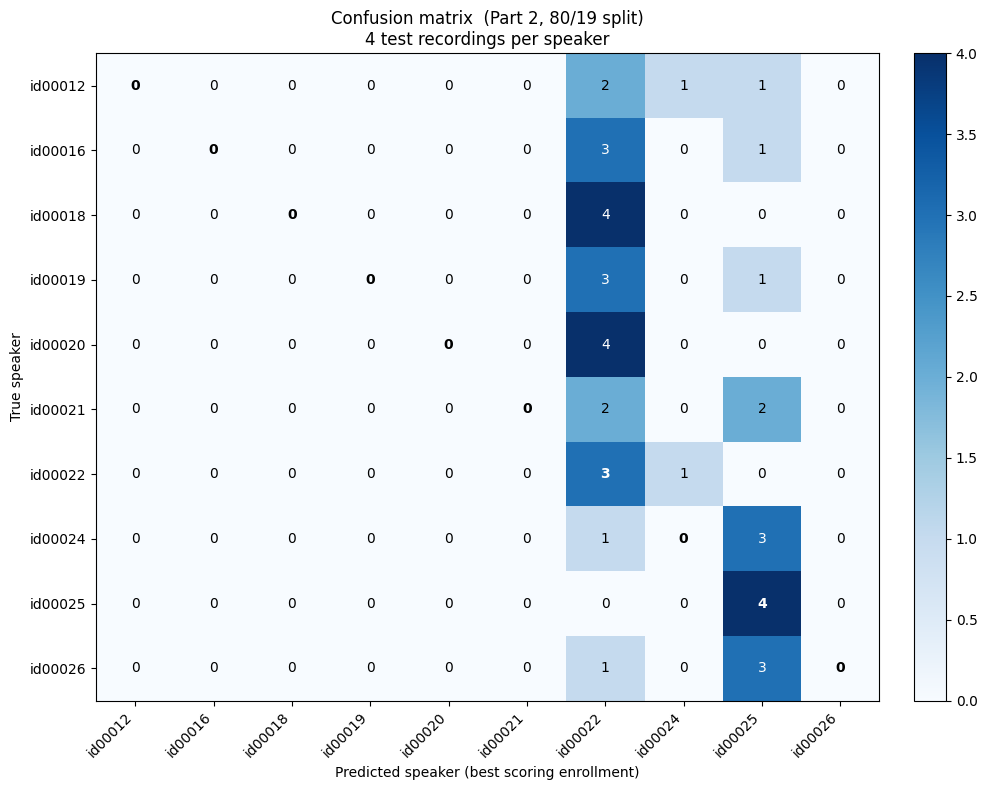

In [16]:
# Confusion: for each probe, which enrollment speaker scored highest?
confusion_2 = (
    best_2.groupby(['test_speaker', 'vs_speaker'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=speakers, columns=speakers, fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion_2.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(speakers)))
ax.set_yticks(range(len(speakers)))
ax.set_xticklabels(speakers, rotation=45, ha='right')
ax.set_yticklabels(speakers)
ax.set_xlabel('Predicted speaker (best scoring enrollment)')
ax.set_ylabel('True speaker')
ax.set_title(
    f'Confusion matrix  (Part 2, {int(ENROLL_RATIO*100)}/{int((1-ENROLL_RATIO)*100)} split)\n'
    f'{n_t} test recordings per speaker'
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

threshold = confusion_2.to_numpy().max() / 2 if confusion_2.size else 0
for i in range(len(speakers)):
    for j in range(len(speakers)):
        v = int(confusion_2.values[i, j])
        color = 'white' if v > threshold else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(v), ha='center', va='center',
                color=color, fontsize=10, fontweight=weight)
plt.tight_layout()
plt.show()

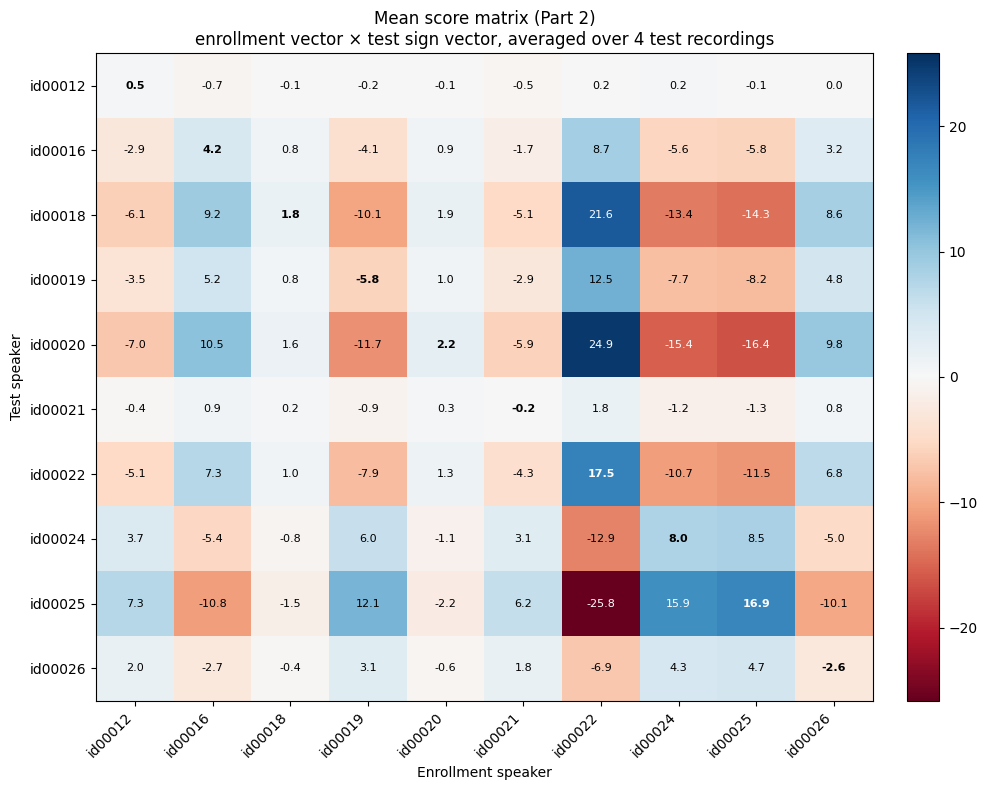

In [17]:
# Average score per (test_speaker, enrollment_speaker) pair
avg_scores_2 = (
    scores_df_2.groupby(['test_speaker', 'vs_speaker'])['score']
    .mean()
    .unstack()
    .reindex(index=speakers, columns=speakers)
)

fig, ax = plt.subplots(figsize=(10, 8))
vmax = max(abs(avg_scores_2.values.min()), abs(avg_scores_2.values.max()))
im = ax.imshow(avg_scores_2.values, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(speakers)))
ax.set_yticks(range(len(speakers)))
ax.set_xticklabels(speakers, rotation=45, ha='right')
ax.set_yticklabels(speakers)
ax.set_xlabel('Enrollment speaker')
ax.set_ylabel('Test speaker')
ax.set_title(
    f'Mean score matrix (Part 2)\n'
    f'enrollment vector \u00d7 test sign vector, averaged over {n_t} test recordings'
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(speakers)):
    for j in range(len(speakers)):
        v = avg_scores_2.values[i, j]
        color = 'white' if abs(v) > vmax * 0.55 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                color=color, fontsize=8, fontweight=weight)
plt.tight_layout()
plt.show()

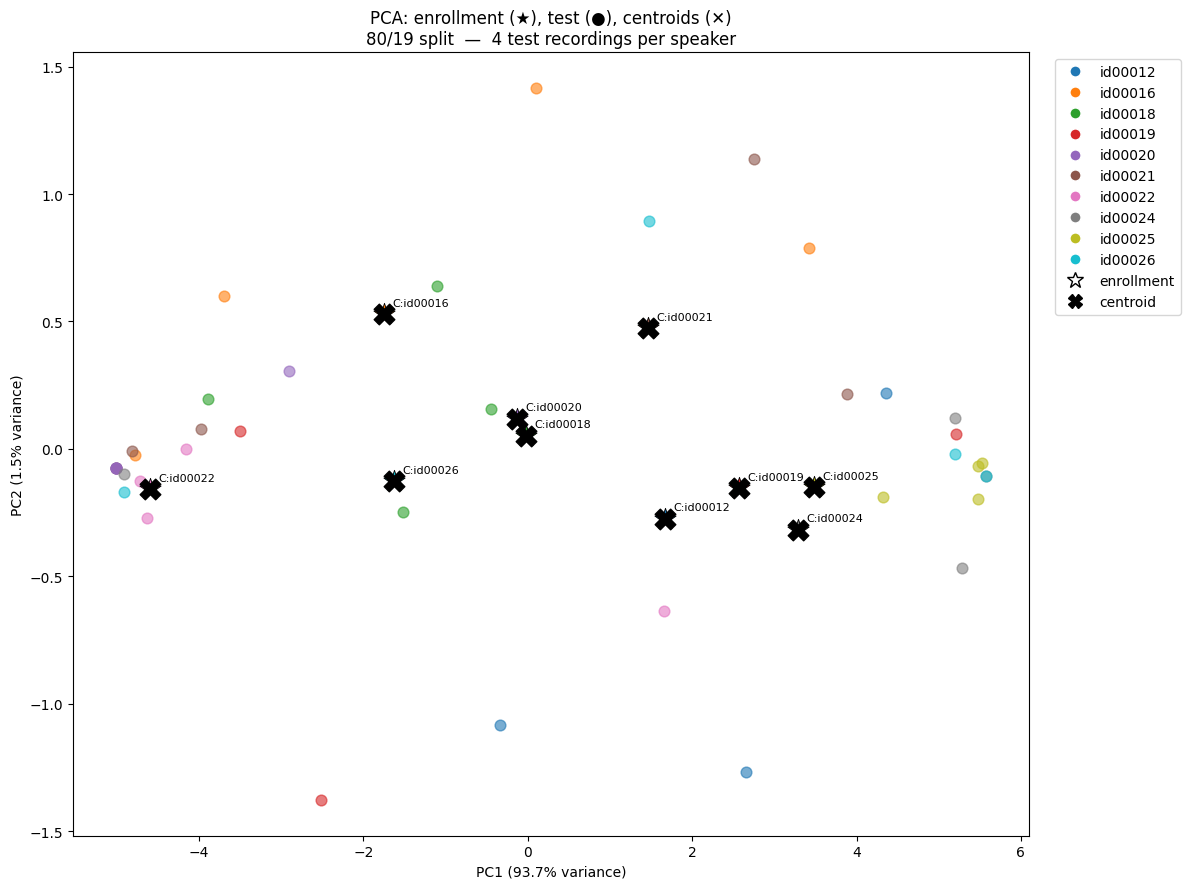

In [18]:
# K-Means on enrollment vectors
n_clusters_2 = len(speakers)
kmeans_2 = KMeans(n_clusters=n_clusters_2, random_state=SEED, n_init='auto')
cluster_labels_2 = kmeans_2.fit_predict(enrollment_matrix_2.values)
centroids_2 = pd.DataFrame(kmeans_2.cluster_centers_, columns=concepts)

cluster_to_speaker_2 = {}
for spk, lbl in zip(enrollment_matrix_2.index, cluster_labels_2):
    cluster_to_speaker_2[int(lbl)] = str(spk)

# PCA data: enrollment + test + centroids
enroll_pca_2 = enrollment_matrix_2.copy()
enroll_pca_2['point_type'] = 'enrollment'
enroll_pca_2['speaker'] = enroll_pca_2.index.astype(str)
enroll_pca_2 = enroll_pca_2.reset_index(drop=True)

test_pca_rows = []
for (spk, tpath), vec in test_raw_2.items():
    row = vec.to_dict()
    row['point_type'] = 'test'
    row['speaker'] = spk
    test_pca_rows.append(row)
test_pca_2 = pd.DataFrame(test_pca_rows)

cent_pca_2 = centroids_2.copy()
cent_pca_2['point_type'] = 'centroid'
cent_pca_2['speaker'] = [cluster_to_speaker_2[i] for i in range(n_clusters_2)]

all_pts_2 = pd.concat([enroll_pca_2, test_pca_2, cent_pca_2], ignore_index=True)

pca_2 = PCA(n_components=2, random_state=SEED)
xy_2 = pca_2.fit_transform(all_pts_2[concepts].values)
all_pts_2['pc1'] = xy_2[:, 0]
all_pts_2['pc2'] = xy_2[:, 1]

# Plot
cmap2 = {spk: plt.cm.tab10(i % 10) for i, spk in enumerate(speakers)}
fig, ax = plt.subplots(figsize=(12, 9))

for spk in speakers:
    ev = all_pts_2[(all_pts_2['point_type'] == 'enrollment') & (all_pts_2['speaker'] == spk)]
    tv = all_pts_2[(all_pts_2['point_type'] == 'test') & (all_pts_2['speaker'] == spk)]
    ax.scatter(ev['pc1'], ev['pc2'], marker='*', s=260, color=cmap2[spk],
               edgecolors='black', linewidths=0.6, zorder=3)
    ax.scatter(tv['pc1'], tv['pc2'], marker='o', s=60, color=cmap2[spk],
               alpha=0.6, zorder=2, label=spk)

cv_2 = all_pts_2[all_pts_2['point_type'] == 'centroid']
ax.scatter(cv_2['pc1'], cv_2['pc2'], marker='X', s=220, color='black', zorder=4)
for _, row in cv_2.iterrows():
    ax.annotate(f'C:{row["speaker"]}', (row['pc1'], row['pc2']),
                textcoords='offset points', xytext=(6, 6), fontsize=8)

handles = [
    Line2D([0], [0], marker='o', color='w', label=s,
           markerfacecolor=cmap2[s], markersize=8)
    for s in speakers
] + [
    Line2D([0], [0], marker='*', color='k', label='enrollment',
           markerfacecolor='w', markersize=12, linewidth=0),
    Line2D([0], [0], marker='X', color='k', label='centroid',
           markerfacecolor='k', markersize=10, linewidth=0),
]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title(
    f'PCA: enrollment (\u2605), test (\u25cf), centroids (\u2715)\n'
    f'{int(ENROLL_RATIO*100)}/{int((1-ENROLL_RATIO)*100)} split  —  '
    f'{n_t} test recordings per speaker'
)
ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

In [19]:
summary_2 = {
    'enroll_ratio': ENROLL_RATIO,
    'n_speakers': len(speakers),
    'n_concepts': len(concepts),
    'enrollment_recordings_per_speaker': n_e,
    'test_recordings_per_speaker': n_t,
    'total_test_probes': n_total_2,
    'identification_accuracy': f'{n_correct_2}/{n_total_2} ({n_correct_2 / n_total_2:.0%})',
    'mean_best_score': round(float(best_2['score'].mean()), 2),
}

print('Summary (Part 2)')
print('\u2500' * 40)
for k, v in summary_2.items():
    print(f'  {k}: {v}')

Summary (Part 2)
────────────────────────────────────────
  enroll_ratio: 0.8
  n_speakers: 10
  n_concepts: 28
  enrollment_recordings_per_speaker: 16
  test_recordings_per_speaker: 4
  total_test_probes: 40
  identification_accuracy: 7/40 (18%)
  mean_best_score: 19.75
